# Amenity Complexity Exploratory Analysis

This notebook demonstrates the workflow for computing amenity complexity using the `amenity_complexity` package.

In [4]:
import pandas as pd
import geopandas as gpd
import contextily as ctx

import matplotlib.pyplot as plt

from amenity_complexity.io import pois_from_foursquare, pois_from_overture
from amenity_complexity.poi import parse_geometry, parse_categories, relevel_categories
from amenity_complexity.geo import load_fuas, bbox_from_fua, load_countries, bbox_from_country, pois_to_h3, aggregate_by_h3, h3_to_polygon
from amenity_complexity.core import compute_complexity

## 1. Load Functional Urban Areas (FUAs)

In [5]:
# Load the FUA dataset (unzipped in data/)
fua_path = '../data/GHS_FUA_UCDB2015_GLOBE_R2019A_54009_1K_V1_0.gpkg'
fuas = load_fuas(fua_path)
print(f"Loaded {len(fuas)} FUAs.")
fuas.head()

Loaded 9031 FUAs.


,eFUA_ID,UC_num,UC_IDs,eFUA_name,Commuting,Cntry_ISO,Cntry_name,FUA_area,UC_area,FUA_p_2015,UC_p_2015,Com_p_2015,geometry
0,1.0,1.0,5959,Herat,1.0,AFG,Afghanistan,139.0,60.0,888811.175807,844574.564331,44236.611476,"MULTIPOLYGON (((62.15405 34.40562, 62.17653 34..."
1,192.0,1.0,5964,Guzarah,1.0,AFG,Afghanistan,32.0,16.0,169489.573231,160204.260864,9285.312366,"MULTIPOLYGON (((62.22457 34.26645, 62.2358 34...."
2,354.0,1.0,5968,Shindand,0.0,AFG,Afghanistan,12.0,12.0,147553.403870,147553.403870,0.000000,"MULTIPOLYGON (((62.15458 33.32066, 62.16573 33..."
3,505.0,1.0,5970,Qala i Naw,0.0,AFG,Afghanistan,3.0,3.0,79809.722656,79809.722656,0.000000,"MULTIPOLYGON (((63.13511 34.98061, 63.11253 34..."
4,648.0,1.0,5973,Farah,1.0,AFG,Afghanistan,32.0,16.0,131508.797060,122843.460327,8665.336733,"MULTIPOLYGON (((62.12915 32.39598, 62.14023 32..."


## 2. Select a Region (e.g., Budapest)
We filter for a specific FUA. You can search by name if available, or ID.

In [7]:
# Example: Search for Budapest
# Note: Column names depend on the dataset. Usually 'eFUA_name' or similar.
target_city = 'Vienna'
city_fua = fuas[fuas['eFUA_name'] == target_city]

if city_fua.empty:
    print(f"{target_city} not found. Showing first 5 names:")
    print(fuas['eFUA_name'].head())
else:
    fua_id = city_fua.iloc[0]['eFUA_ID']
    print(f"Found {target_city} with ID: {fua_id}")
    bbox = bbox_from_fua(fuas, 'eFUA_ID', fua_id)
    print(f"BBox: {bbox}")

Found Vienna with ID: 790.0
BBox: (15.828431709164791, 47.78154121350172, 16.908136838053615, 48.55916103849195)


## 3. Load POIs
We fetch POIs from Foursquare (via DuckDB) within the bounding box.

In [8]:
pois_fsq = pois_from_foursquare(bbox=bbox, trim_cols=True)
print(f"Loaded {len(pois_fsq)} POIs.")
pois_fsq.head()

Loaded 196316 POIs.


,id,name,top_category,sub_category,longitude,latitude,operating_status
0,5365c2e3498e4ed27d2fb162,Zicksee,Landmarks and Outdoors,Surf Spot,16.899481,47.782440,None
1,4c1a3d7bb9f876b0534c7846,Zicksee,Landmarks and Outdoors,Lake,16.900012,47.783301,None
2,c7565b134316415abf688d96,Mag. Alois Tschida,Dining and Drinking,Restaurant,16.785141,47.782681,None
3,502a3d6ee4b06703002e3c71,Nationalpark Info Illmitz,Arts and Entertainment,Amusement Park,16.791806,47.795917,None
4,4e6a5143227162c38e60c199,Blamuka Probenlokal,Arts and Entertainment,Performing Arts Venue,16.312642,47.785041,None


In [9]:
pois_omf = pois_from_overture(bbox=bbox, trim_cols=True)
print(f"Loaded {len(pois_omf)} POIs.")
pois_omf.head()

Loaded 102281 POIs.


,id,name,top_category,sub_category,longitude,latitude,operating_status
0,f34e4f41-f8f6-45cf-9cd9-85cb47105c49,"Althof-Reitstall, Jausenstation, Ferienwohnungen",animal_boarding,equestrian_facility,16.892112,47.825252,open
1,4c2abb7c-ab2c-488a-9149-23544432a0ec,Grundlacke,historic_site,fountain,16.875002,47.829726,open
2,52353f88-da75-4452-9ff8-1ff203c57add,Weingut Judith Beck,winery,liquor_store,16.908103,47.898219,open
3,c01c91ce-b198-475d-9686-ab61669e4cc7,Raiffeisenlandesbank Burgenland,financial_service,business_banking_service,16.908008,47.898258,open
4,aa2a5fc0-5ba3-439b-aa1d-78b6faadf706,Gsellmann Wohnen,accommodation,landmark_and_historical_building,16.905834,47.899528,open


In [10]:
# pois_fsq = parse_geometry(pois_fsq, crs='EPSG:3035')
# pois_omf = parse_geometry(pois_omf, crs='EPSG:3035')

## 4. Aggregate to H3 Cells

In [11]:
resolution = 8
pois_fsq = pois_to_h3(pois_fsq, 'latitude', 'longitude', resolution, geometry=False)
pois_omf = pois_to_h3(pois_omf, 'latitude', 'longitude', resolution, geometry=False)
matrix_fsq = aggregate_by_h3(pois_fsq, 'h3_lvl8', 'top_category')
matrix_omf = aggregate_by_h3(pois_omf, 'h3_lvl8', 'top_category')
print(f"Comparison: {matrix_fsq.shape} x {matrix_omf.shape}")

Comparison: (4255, 10) x (3777, 362)


## 5. Compute Complexity

In [55]:
profile = compute_complexity(
    pois_fsq,
    unit_col="h3_lvl8",
    category_col="sub_category",
    methods=("juhasz", "hidalgo"),
)

In [56]:
profile.units.head()

,n_amenities,n_categories,diversity_rca,complexity_juhasz,complexity_hidalgo
h3_lvl8,,,,,
881e02c025fffff,58,26,22,-1.876258,0.015281
881e02c027fffff,35,17,14,-0.925823,0.015281
881e02c02dfffff,5,5,5,0.040235,0.015281
881e02c03dfffff,1,1,1,0.460094,0.015281
881e02c041fffff,1,1,1,0.419815,0.015281


In [57]:
profile.categories.head()

,ubiquity_rca,complexity_juhasz,complexity_hidalgo
sub_category,,,
AIDS Resource,2,-0.280734,-0.021836
Acupuncture Clinic,50,0.536122,-0.021836
Addiction Treatment Center,4,-0.308216,-0.021836
Adult Store,29,0.278007,-0.021836
Advertising Agency,549,-1.104898,-0.021836


## 6. Visualize
We can join the results back to geometries (H3 polygons) and plot.

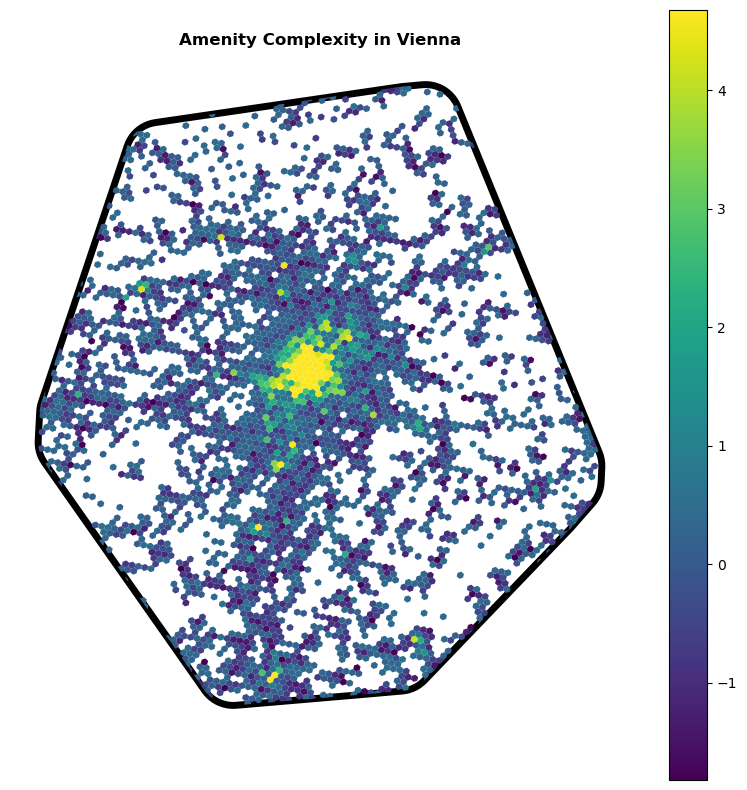

In [71]:
results = profile.units
results['geometry'] = results.index.map(h3_to_polygon)
results = gpd.GeoDataFrame(results, crs="EPSG:4326").to_crs("EPSG:3035")
boundary = city_fua.to_crs("EPSG:3035").geometry.convex_hull.buffer(5000)

# winsorise the results
results['complexity_juhasz'] = results['complexity_juhasz'].clip(
    lower=results['complexity_juhasz'].quantile(0.01), 
    upper=results['complexity_juhasz'].quantile(0.99)
)

# clip to the FUA
results = results.clip(boundary)

fig, ax = plt.subplots(figsize=(10, 10))
boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=5)
results.plot(column='complexity_juhasz', ax=ax, legend=True, cmap='viridis')

ax.set_axis_off()
ax.set_aspect('equal')

plt.title(f"Amenity Complexity in {target_city}", weight='bold' )
plt.show()